In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import norm



In [4]:
df = pd.read_csv('bhp - bhp.csv')

In [5]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.000000,13200.000000,13200.000000,13200.000000,1.320000e+04
mean,1555.302783,2.691136,112.276178,2.800833,7.920337e+03
std,1237.323445,1.338915,149.175995,1.292843,1.067272e+05
min,1.000000,1.000000,8.000000,1.000000,2.670000e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.267000e+03
50%,1275.000000,2.000000,71.850000,3.000000,5.438000e+03
75%,1672.000000,3.000000,120.000000,3.000000,7.317000e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


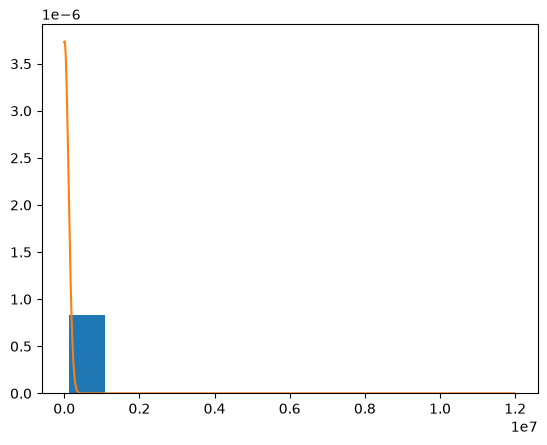

In [24]:
matplotlib.rcParams['figure.figsize']

plt.hist(df['price_per_sqft'], bins=10, rwidth=0.8, density=True)
rng = np.arange(df.price_per_sqft.min(), df.price_per_sqft.max(), 1)
plt.plot(rng, norm.pdf(rng, df.price_per_sqft.mean(), df.price_per_sqft.std()))
plt.show()

### Quantile


In [25]:
lower_treshold = df['price_per_sqft'].quantile(0.001)
upper_treshold = df['price_per_sqft'].quantile(0.999)

In [26]:
outliers_quantile = df[(df['price_per_sqft'] < lower_treshold) | (df['price_per_sqft'] > upper_treshold)]
outliers_quantile.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3,74.0,3,672727
665,Yelahanka,3 BHK,35000.0,3,130.0,3,371
798,other,4 Bedroom,10961.0,4,80.0,4,729
1005,other,1 BHK,15.0,1,30.0,1,200000
1106,other,5 Bedroom,24.0,2,150.0,5,625000


In [27]:
df_cleaned = df[(df['price_per_sqft'] >= lower_treshold) & (df['price_per_sqft'] <= upper_treshold)]
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 13172 entries, 0 to 13199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13172 non-null  str    
 1   size            13172 non-null  str    
 2   total_sqft      13172 non-null  float64
 3   bath            13172 non-null  int64  
 4   price           13172 non-null  float64
 5   bhk             13172 non-null  int64  
 6   price_per_sqft  13172 non-null  int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 823.2 KB


Text(0.5, 1.0, 'Cleaned price_per_sqft')

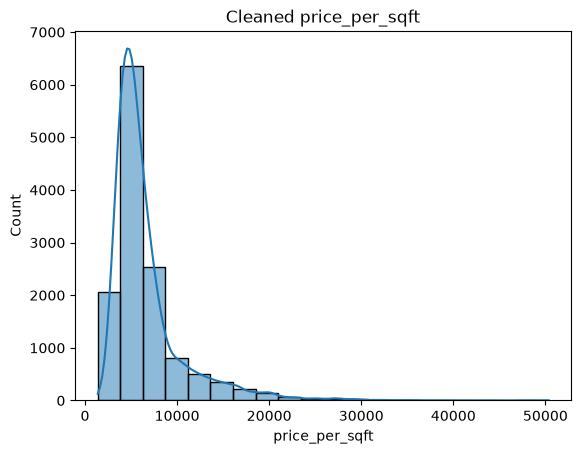

In [28]:
sns.histplot(df_cleaned['price_per_sqft'], bins=20,kde=True)
plt.title("Cleaned price_per_sqft")

In [40]:
print(df.shape, df_cleaned.shape)

(13200, 7) (13172, 7)


In [1]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df['price_per_sqft'], bins=20, rwidth=0.8, density=True)
plt.title("Og data")

plt.subplot(1,2,2)
plt.hist(df_cleaned['price_per_sqft'], bins=20, rwidth=0.8, density=True)
plt.title("Cleaned data")

NameError: name 'plt' is not defined

### Std dev

In [47]:
mean_price_per_sqft = df_cleaned.price_per_sqft.mean()
std_price_per_sqft = df_cleaned.price_per_sqft.std()
print(mean_price_per_sqft, std_price_per_sqft)

6663.6537351958705 4141.020700174612


In [48]:
upper_limit = mean_price_per_sqft + 4*std_price_per_sqft
lower_limit = mean_price_per_sqft - 4*std_price_per_sqft
print(upper_limit, lower_limit)

23227.73653589432 -9900.429065502578


In [49]:
outliers = df_cleaned[(df_cleaned['price_per_sqft'] < lower_limit) | (df_cleaned['price_per_sqft'] > upper_limit)]
outliers

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6,370.0,6,36274
45,HSR Layout,8 Bedroom,600.0,9,200.0,8,33333
190,Bellandur,4 Bedroom,1200.0,5,325.0,4,27083
733,Cunningham Road,4 BHK,5270.0,4,1250.0,4,23719
760,other,9 Bedroom,600.0,9,190.0,9,31666
...,...,...,...,...,...,...,...
13081,other,6 Bedroom,8000.0,6,2800.0,6,35000
13094,other,4 Bedroom,1200.0,5,325.0,4,27083
13127,other,4 Bedroom,1200.0,5,325.0,4,27083
13185,Hulimavu,1 BHK,500.0,1,220.0,1,44000


In [51]:
df_clean_std = df_cleaned[(df_cleaned['price_per_sqft'] > lower_limit) & (df_cleaned['price_per_sqft'] < upper_limit)]
print(df_clean_std.shape[0],
df.shape[0])

13047 13200


Text(0.5, 1.0, 'Cleaned data')

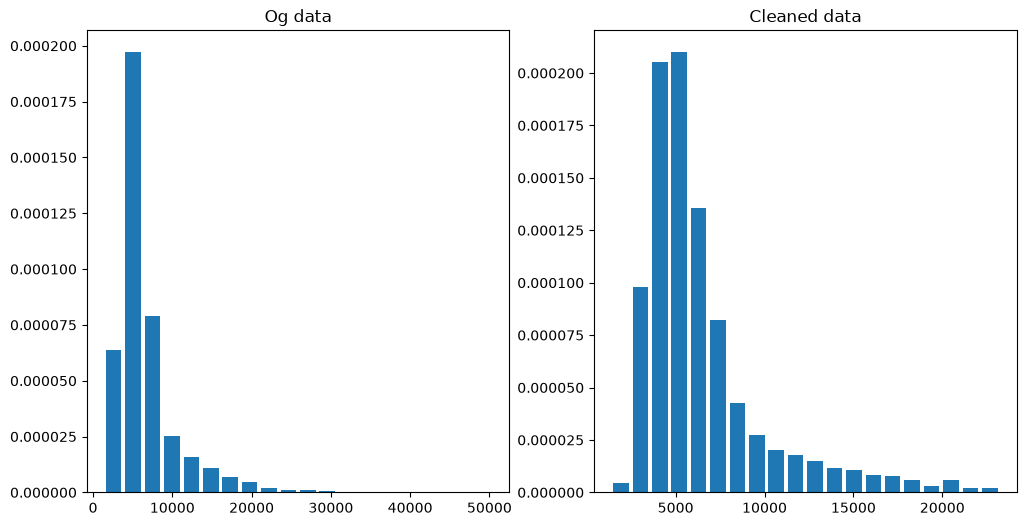

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df_cleaned['price_per_sqft'], bins=20, rwidth=0.8, density=True)
plt.title("Og cleaned data")

plt.subplot(1,2,2)
plt.hist(df_clean_std['price_per_sqft'], bins=20, rwidth=0.8, density=True)
plt.title("Cleaned data")

### Z-Score


In [54]:
df_zscore = df_cleaned.copy()

df_zscore['z_score'] = (df_zscore['price_per_sqft']- df_zscore['price_per_sqft'].mean())/df_zscore['price_per_sqft'].std()
df_zscore.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699,-0.715923
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615,-0.494722
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305,-0.569583
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245,-0.101099
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250,-0.582864


In [2]:
outliers_zscore = df_zscore[(df_zscore['z_score'] < -4) | (df_zscore['z_score'] >4)]

NameError: name 'df_zscore' is not defined

In [59]:
print(outliers_zscore.shape[0])

125


In [60]:
df_zscore_cleaned = df_zscore[(df_zscore['z_score'] > -4) & (df_zscore['z_score'] <4)]

Text(0.5, 1.0, 'Cleaned data')

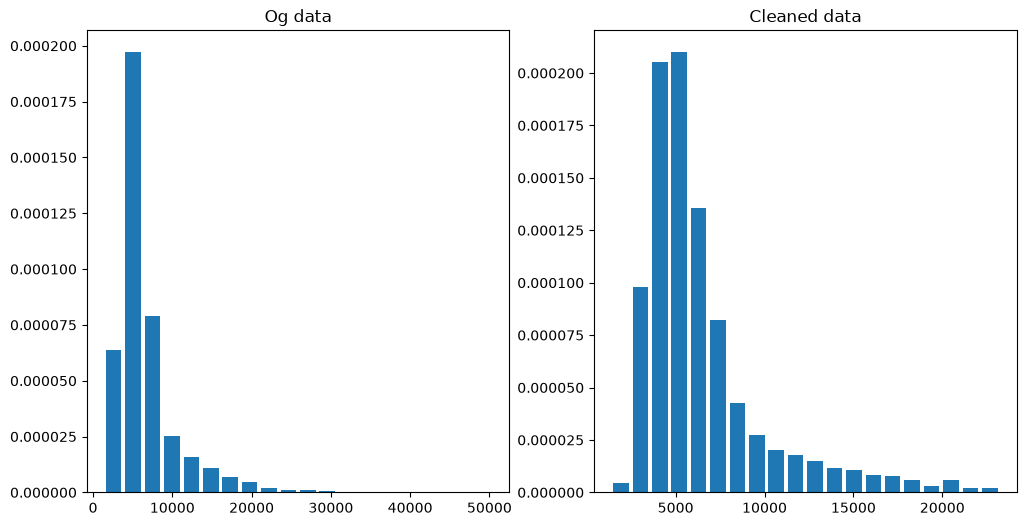

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df_cleaned['price_per_sqft'], bins=20, rwidth=0.8, density=True)
plt.title("percentile cleaned data")

plt.subplot(1,2,2)
plt.hist(df_zscore_cleaned['price_per_sqft'], bins=20, rwidth=0.8, density=True)
plt.title("Cleaned data")

Practice Assingment-03

Exercise: Outlier Detection and Removal using Quantile, Standard Deviation and Z-score Methods

Problem Statement

Use Banglore House price_per_sqfts (`bhp.csv`) dataset which contains extreme outliers in the `price_per_sqft_per_sqft` column, which can negatively affect machine learning model accuracy.

Your task is to clean this data by removing these outliers.

Tasks to be Performed:
Detect and Remove outliers using the Percentile Method with a [0.001, 0.999] range.
On the cleaned data, detect and remove further outliers using the Standard Deviation Method with a threshold of 4 standard deviations.
Plot a histogram with a bell curve on the final dataset to visualize the cleaned distribution.
Explain how the Z-Score Method is equivalent to the Standard Deviation Method for this task.